## What TF-IDF Does

TF-IDF scores each word in an error message by how useful it is for 
telling categories apart. A word that shows up in almost every error 
(like "error" or "line") gets a low score, since it doesn't help 
distinguish one category from another. A word that's rare but specific 
to certain errors (like "subscriptable" or "iterable") gets a high 
score, since seeing it strongly suggests a particular category. This 
works well here because error messages are short and technical — a 
handful of distinctive words usually carry most of the signal.

In [1]:
import sys, os

project_root = r"D:\DevMentor AI"
if os.getcwd() != project_root:
    os.chdir(project_root)
sys.path.insert(0, project_root)

print("Working directory:", os.getcwd())

Working directory: D:\DevMentor AI


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from client.runner import get_output_error, parse_error
from sanitizer.sanitizer import sanitize

print("Imports successful")

Imports successful


In [3]:
def make_row(code_snippet: str, label: str) -> dict:
    """Runs a code snippet, captures its error message, sanitizes it,
    and returns a dataset row. Returns None if the snippet didn't error."""
    import subprocess
    result = subprocess.run(
        [sys.executable, "-c", code_snippet],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        return None

    parsed = parse_error(result.stderr)
    if not parsed:
        return None

    error_type, message = parsed
    return {"text": sanitize(message), "label": label}


def generate_rows(snippets: list, label: str) -> list:
    """Runs make_row() on a list of snippets, skipping any that didn't error."""
    rows = []
    for s in snippets:
        row = make_row(s, label)
        if row:
            rows.append(row)
    return rows

In [4]:
key_error_snippets = [
    'user = {"name": "apurv"}; print(user["email"])',
    'config = {"debug": True}; print(config["timeout"])',
    'data = {"id": 1, "name": "test"}; print(data["value"])',
    'settings = {"theme": "dark"}; print(settings["language"])',
    'response = {"status": 200}; print(response["body"])',
    'cache = {}; print(cache["missing_key"])',
    'headers = {"Content-Type": "json"}; print(headers["Authorization"])',
    'params = {"page": 1}; print(params["limit"])',
    'record = {"id": 5}; print(record["timestamp"])',
    'payload = {"user_id": 42}; print(payload["session_token"])',
    'options = {"verbose": False}; print(options["quiet"])',
    'metadata = {"version": "1.0"}; print(metadata["build"])',
]

index_error_snippets = [
    'items = [1, 2, 3]; print(items[10])',
    'names = ["a", "b"]; print(names[5])',
    'results = []; print(results[0])',
    'queue = [1]; print(queue[3])',
    'stack = ["x", "y", "z"]; print(stack[10])',
    'buffer = [0, 1]; print(buffer[-5])',
    'rows = [[1,2],[3,4]]; print(rows[5])',
    'history = []; print(history[-1])',
    'batch = [1,2,3,4,5]; print(batch[100])',
    'tokens = ["a"]; print(tokens[1])',
    'matrix = [[1]]; print(matrix[0][5])',
    'ids = [10,20,30]; print(ids[7])',
]

type_error_snippets = [
    'x = 5 + "text"',
    'y = "hello" + 10',
    'z = [1,2] + "a"',
    'result = None + 5',
    'val = len(5)',
    'combined = {} + {}',
    'output = 3 / "two"',
    'items = [1,2,3]; items + 5',
    'name = "test"; name()',
    'count = 10; count["key"]',
    'value = True + "yes"',
]

none_type_error_snippets = [
    'x = None; print(x.upper())',
    'data = None; print(data["key"])',
    'result = None; print(len(result))',
    'user = None; print(user.name)',
    'response = None; print(response["status"])',
    'value = None; print(value + 5)',
    'obj = None; obj.method()',
    'items = None; print(items[0])',
    'config = None; print(config.get("key"))',
    'total = None; print(total * 2)',
    'record = None; print(record.id)',
    'output = None; print(output.append(1))',
]

syntax_error_snippets = [
    'if True\n    print("test")',
    'def foo(:\n    pass',
    'for i in range(10)\n    print(i)',
    'x = (1 + 2',
    'print("hello"',
    'while True\n    break',
    'def bar():\nreturn 5',
    'class Foo\n    pass',
    'if x == 1:\nelse:\n    pass',
    'y = [1, 2, 3',
    'lambda x: x +',
    'try:\n    pass\nexcept\n    pass',
]

attribute_error_snippets = [
    'x = 5; x.append(1)',
    'name = "test"; name.push("x")',
    'items = [1,2,3]; items.get("key")',
    'num = 10; num.upper()',
    'data = {"a": 1}; data.append(2)',
    'value = 3.14; value.split(",")',
    'flag = True; flag.lower()',
    'text = "hello"; text.add("x")',
    'lst = [1,2]; lst.keys()',
    'n = 5; n.strip()',
    'obj = object(); obj.missing_method()',
    'tup = (1,2); tup.append(3)',
]

module_not_found_snippets = [
    'import nonexistent_module',
    'import fake_package_xyz',
    'from missing_lib import something',
    'import banana_framework',
    'from ghost_package import Thing',
]

file_not_found_snippets = [
    'open("missing_file.txt")',
    'open("does_not_exist.csv")',
    'open("/nonexistent/path/file.txt")',
    'open("no_such_report.pdf")',
    'open("phantom_script.py")',
]

value_error_snippets = [
    'int("abc")',
    'int("twelve")',
    'float("not_a_number")',
    'int("")',
    'int("12a")',
    'float("1,000")',
]

network_error_snippets = [
    'import requests; requests.get("http://127.0.0.1:1", timeout=1)',
    'import requests; requests.get("http://127.0.0.1:2", timeout=1)',
    'import requests; requests.get("http://localhost:9999", timeout=1)',
]

permission_error_snippets = [
    'open("readonly.txt", "a")',
    'open("readonly.txt", "w")',
]

other_error_snippets = [
    'raise NotImplementedError("This feature is not built yet")',
    'raise OverflowError("Result too large to represent")',
]

print("All snippet lists loaded")

All snippet lists loaded


In [5]:
key_error_rows = generate_rows(key_error_snippets, "key_error")
index_error_rows = generate_rows(index_error_snippets, "index_error")
type_error_rows = generate_rows(type_error_snippets, "type_error")
none_type_error_rows = generate_rows(none_type_error_snippets, "none_type_error")
syntax_error_rows = generate_rows(syntax_error_snippets, "syntax_error")
attribute_error_rows = generate_rows(attribute_error_snippets, "attribute_error")
module_not_found_rows = generate_rows(module_not_found_snippets, "module_not_found")
file_not_found_rows = generate_rows(file_not_found_snippets, "file_not_found")
value_error_rows = generate_rows(value_error_snippets, "value_error")
network_error_rows = generate_rows(network_error_snippets, "network_error")
permission_error_rows = generate_rows(permission_error_snippets, "permission_error")
other_error_rows = generate_rows(other_error_snippets, "other_error")

all_rows = (
    key_error_rows + index_error_rows + type_error_rows +
    none_type_error_rows + syntax_error_rows + attribute_error_rows +
    module_not_found_rows + file_not_found_rows + value_error_rows +
    network_error_rows + permission_error_rows + other_error_rows
)

df = pd.DataFrame(all_rows)
print("Total rows before trim:", df.shape)
print(df["label"].value_counts())

Total rows before trim: (94, 2)
label
key_error           12
index_error         12
none_type_error     12
syntax_error        12
attribute_error     12
type_error          11
value_error          6
module_not_found     5
file_not_found       5
network_error        3
permission_error     2
other_error          2
Name: count, dtype: int64


In [6]:
df = df.groupby(["text", "label"]).head(3).reset_index(drop=True)
print("Total rows after trim:", df.shape)
print(df["label"].value_counts())

Total rows after trim: (83, 2)
label
key_error           12
none_type_error     12
attribute_error     12
type_error          11
syntax_error        10
value_error          6
module_not_found     5
file_not_found       5
index_error          3
network_error        3
permission_error     2
other_error          2
Name: count, dtype: int64


In [7]:
df.to_csv("ml_engine/data/labeled/dataset.csv", index=False)
print("Saved:", df.shape)

Saved: (83, 2)


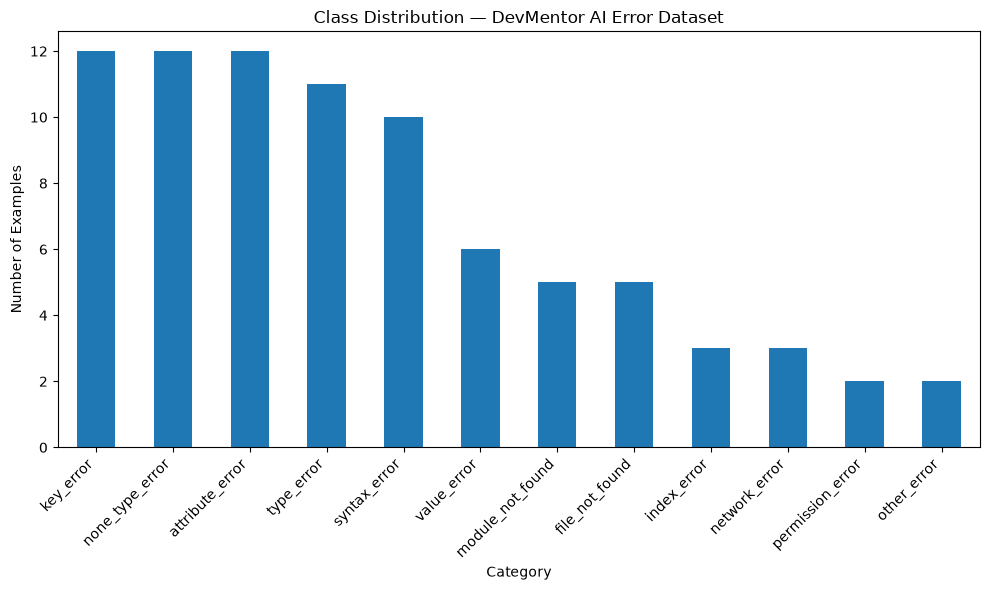

In [8]:
plt.figure(figsize=(10, 6))
df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution — DevMentor AI Error Dataset")
plt.xlabel("Category")
plt.ylabel("Number of Examples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("ml_engine/models/class_distribution.png")
plt.show()

In [9]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", len(X_train), "| Test size:", len(X_test))
print("\nTrain label counts:\n", y_train.value_counts())
print("\nTest label counts:\n", y_test.value_counts())
print("\nCategories in test set:", y_test.nunique(), "out of", y.nunique())

Train size: 66 | Test size: 17

Train label counts:
 label
key_error           10
attribute_error      9
none_type_error      9
type_error           9
syntax_error         8
value_error          5
file_not_found       4
module_not_found     4
network_error        2
permission_error     2
other_error          2
index_error          2
Name: count, dtype: int64

Test label counts:
 label
attribute_error     3
none_type_error     3
syntax_error        2
key_error           2
type_error          2
value_error         1
file_not_found      1
module_not_found    1
network_error       1
index_error         1
Name: count, dtype: int64

Categories in test set: 10 out of 12


In [10]:
missing = set(y.unique()) - set(y_test.unique())
print("Missing from test set:", missing)

Missing from test set: {'permission_error', 'other_error'}


In [11]:
extra_network_error_snippets = [
    'import requests; requests.get("http://127.0.0.1:3", timeout=1)',
    'import requests; requests.get("http://192.0.2.1:80", timeout=1)',
]

extra_permission_error_snippets = [
    'open("readonly.txt", "r+")',
]

extra_other_error_snippets = [
    'raise ArithmeticError("Something went wrong mathematically")',
    'raise LookupError("Could not find the requested item")',
]

extra_rows = (
    generate_rows(extra_network_error_snippets, "network_error") +
    generate_rows(extra_permission_error_snippets, "permission_error") +
    generate_rows(extra_other_error_snippets, "other_error")
)

df = pd.concat([df, pd.DataFrame(extra_rows)], ignore_index=True)
df = df.groupby(["text", "label"]).head(3).reset_index(drop=True)

print(df.shape)
print(df["label"].value_counts())

(88, 2)
label
key_error           12
none_type_error     12
attribute_error     12
type_error          11
syntax_error        10
value_error          6
module_not_found     5
file_not_found       5
network_error        5
other_error          4
index_error          3
permission_error     3
Name: count, dtype: int64


In [12]:
df.to_csv("ml_engine/data/labeled/dataset.csv", index=False)

X = df["text"]
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Categories in test set:", y_test.nunique(), "out of", y.nunique())

Categories in test set: 12 out of 12
